In [1]:
### First read both revcomp and forward var effects
import pandas as pd

forward = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai.csv.gz", compression="gzip")
reverse = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai_revcomp.csv.gz", compression="gzip")

### Have to switch the column labels for the forward df
rename_dict = {}
for col in forward.columns:
    if col.startswith("offset_"):
        pos = int(col.split("_")[1])
        flipped_col = f"offset_{-pos}"
        rename_dict[col] = flipped_col

# Apply the renaming
forward = forward.rename(columns=rename_dict)

In [2]:
### Now change the values
offset_cols = [col for col in forward.columns if col.startswith("offset_")]
forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]

reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
reverse["seq_id"] = ["seq_rev_" + str(i + 1) for i in range(len(reverse))]

/tmp/ipykernel_1761858/2042737668.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_1761858/2042737668.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)


In [3]:
### Combine and filter out the rows
forward["strand"] = "forward"
reverse["strand"] = "reverse"
combined = pd.concat([forward, reverse], ignore_index=True)
offset_cols = [col for col in combined.columns if col.startswith("offset_")]
# filtered = combined[combined[offset_cols].apply(
#     lambda row: (row > 0.15).any() or (row < -0.15).any(), axis=1)]
filtered = combined
print(len(filtered))

206706


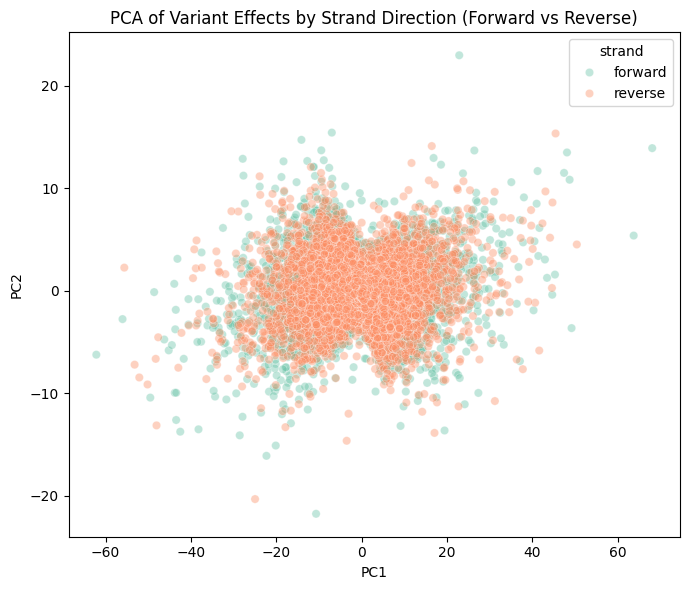

Explained variance (first few PCs): [0.80209495 0.08750667 0.04234044 0.02011286 0.01268706]


In [4]:
### Now run PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


offset_cols = [col for col in filtered.columns if col.startswith("offset_")]
X = filtered[offset_cols].values

X_std = StandardScaler().fit_transform(X)

pca = PCA() 
X_pca = pca.fit_transform(X_std)

for i in range(X_pca.shape[1]):
    filtered[f'PC{i+1}'] = X_pca[:, i]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=filtered, x="PC1", y="PC2", hue="strand", palette="Set2", alpha=0.4)
plt.title("PCA of Variant Effects by Strand Direction (Forward vs Reverse)")
plt.tight_layout()
plt.savefig('/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/PCA_full.svg', format='svg')
plt.show()

print("Explained variance (first few PCs):", pca.explained_variance_ratio_[:5])


### Color the dataframes by var effects

In [5]:
# Identify offset columns again (just to be safe)
offset_cols = [col for col in combined.columns if col.startswith("offset_")]

# Add threshold column: check if *all* variant effects are within [-0.25, 0.25]
combined["var_threshold"] = combined[offset_cols].apply(
    lambda row: "Low effect (within ±0.25)" if row.abs().le(0.25).any() else "High effect (outside ±0.25)",
    axis=1
)


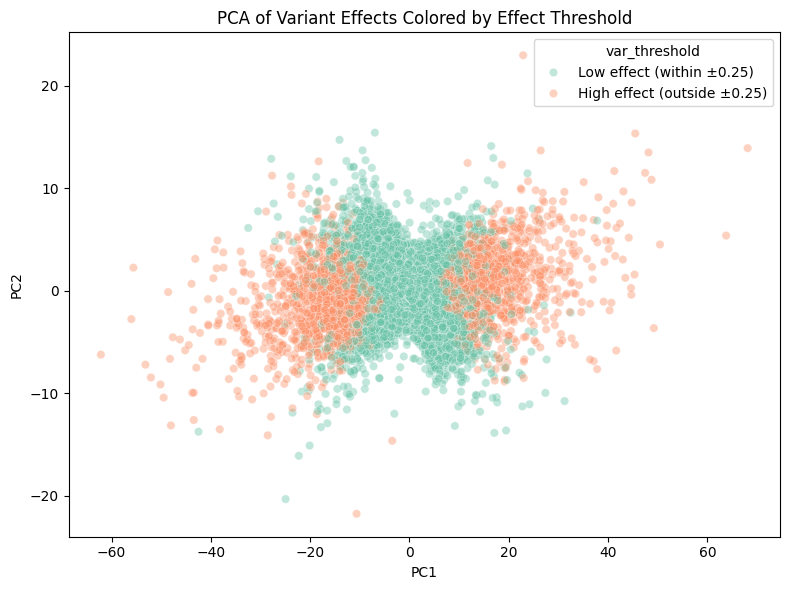

Explained variance (first few PCs): [0.80209495 0.08750667 0.04234044 0.02011286 0.01268706]


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = combined[offset_cols].values
X_std = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_std)

for i in range(X_pca.shape[1]):
    combined[f"PC{i+1}"] = X_pca[:, i]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=combined,
    x="PC1",
    y="PC2",
    hue="var_threshold",
    palette={"Low effect (within ±0.25)": "#66c2a5", "High effect (outside ±0.25)": "#fc8d62"},
    alpha=0.4
)
plt.title("PCA of Variant Effects Colored by Effect Threshold")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/PCA_var_effect_threshold.svg", format="svg")
plt.show()

print("Explained variance (first few PCs):", pca.explained_variance_ratio_[:5])


### tSNE clustering: try a different way of doing clustering

In [7]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import seaborn as sns

# combined_sampled = combined.sample(n=20000, random_state=42)
# X_std_sampled = X_std[combined_sampled.index]
# tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)

# # Run t-SNE on standardized data
# X_tsne = tsne.fit_transform(X_std_sampled)

# # Add to your `combined` DataFrame
# combined_sampled["TSNE1"] = X_tsne[:, 0]
# combined_sampled["TSNE2"] = X_tsne[:, 1]

# # Plot
# plt.figure(figsize=(8, 6))
# sns.scatterplot(
#     data=combined_sampled,
#     x="TSNE1",
#     y="TSNE2",
#     hue="var_threshold",
#     palette={"Low effect (within ±0.25)": "#66c2a5", "High effect (outside ±0.25)": "#fc8d62"},
#     alpha=0.4
# )
# plt.title("t-SNE of Variant Effects Colored by Effect Threshold")
# plt.tight_layout()
# plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/TSNE_var_effect_threshold.svg", format="svg")
# plt.show()


### Run hierarchical clustering

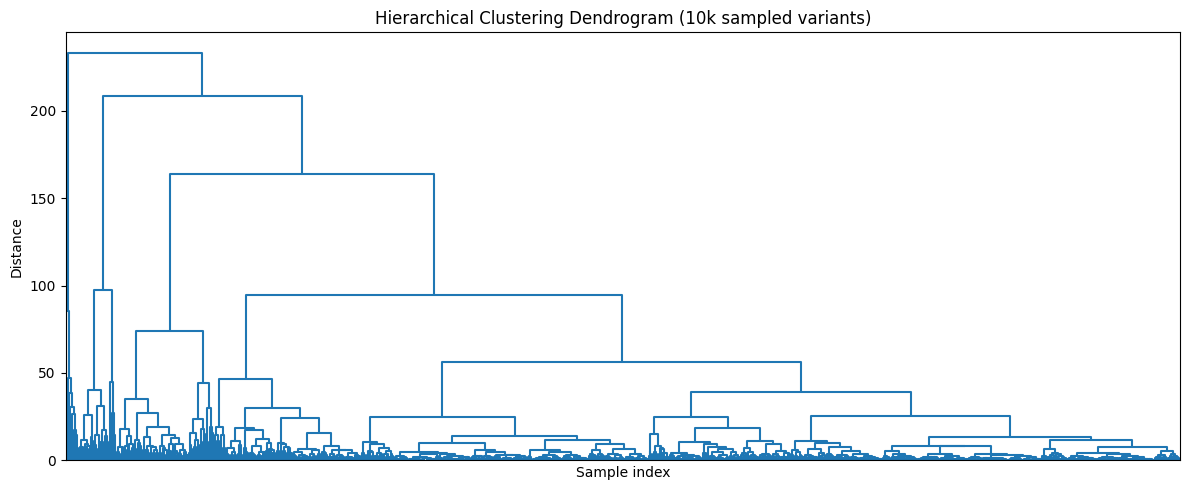

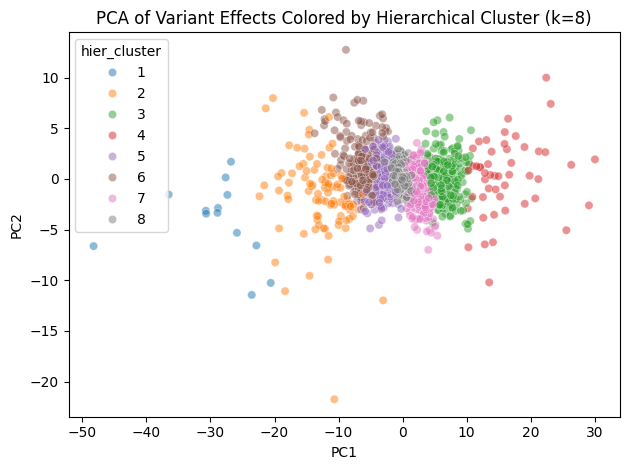

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

combined_sampled = combined.sample(n=10000, random_state=42)
X_sampled = combined_sampled[offset_cols].values
X_sampled_std = StandardScaler().fit_transform(X_sampled)

linkage_matrix = linkage(X_sampled_std, method="ward")


combined_sampled["hier_cluster"] = fcluster(linkage_matrix, 8, criterion='maxclust')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
plt.title("Hierarchical Clustering Dendrogram (10k sampled variants)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

sns.scatterplot(
    data=combined_sampled,
    x="PC1",
    y="PC2",
    hue="hier_cluster",
    palette="tab10",
    alpha=0.5
)
plt.title("PCA of Variant Effects Colored by Hierarchical Cluster (k=8)")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/PCA_hierarchical_clusters.svg", format="svg")
plt.show()

### DBSCAN

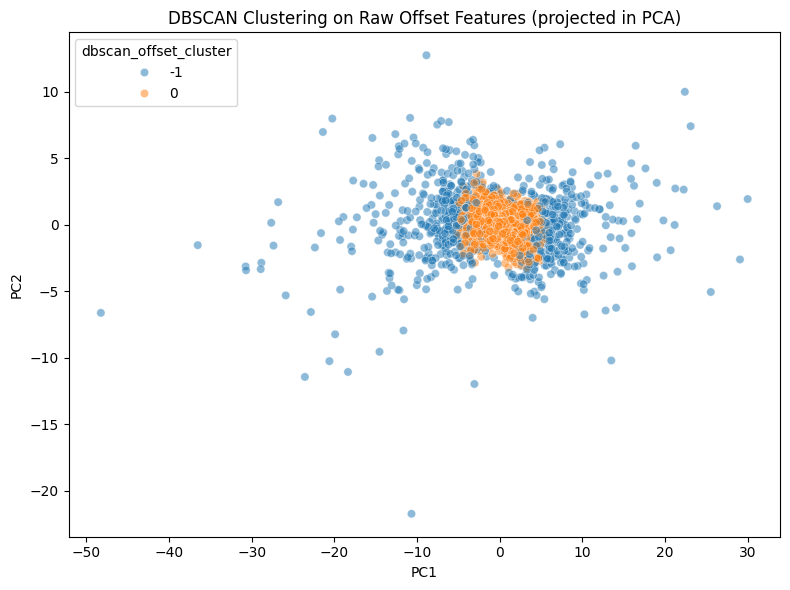

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

combined_sampled = combined.sample(n=10000, random_state=42)
X_sampled = combined_sampled[offset_cols].values
X_sampled_std = StandardScaler().fit_transform(X_sampled)

dbscan = DBSCAN(eps=1.5, min_samples=10)  # <-- tune eps as needed
dbscan_labels = dbscan.fit_predict(X_sampled_std)


combined_sampled["dbscan_offset_cluster"] = dbscan_labels  # -1 = noise


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=combined_sampled,
    x="PC1",  # assume PCA was already computed earlier
    y="PC2",
    hue="dbscan_offset_cluster",
    palette="tab10",
    alpha=0.5,
    legend='full'
)
plt.title("DBSCAN Clustering on Raw Offset Features (projected in PCA)")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/DBSCAN_on_offset_features.svg", format="svg")
plt.show()


### Cluster heatmap

21303


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


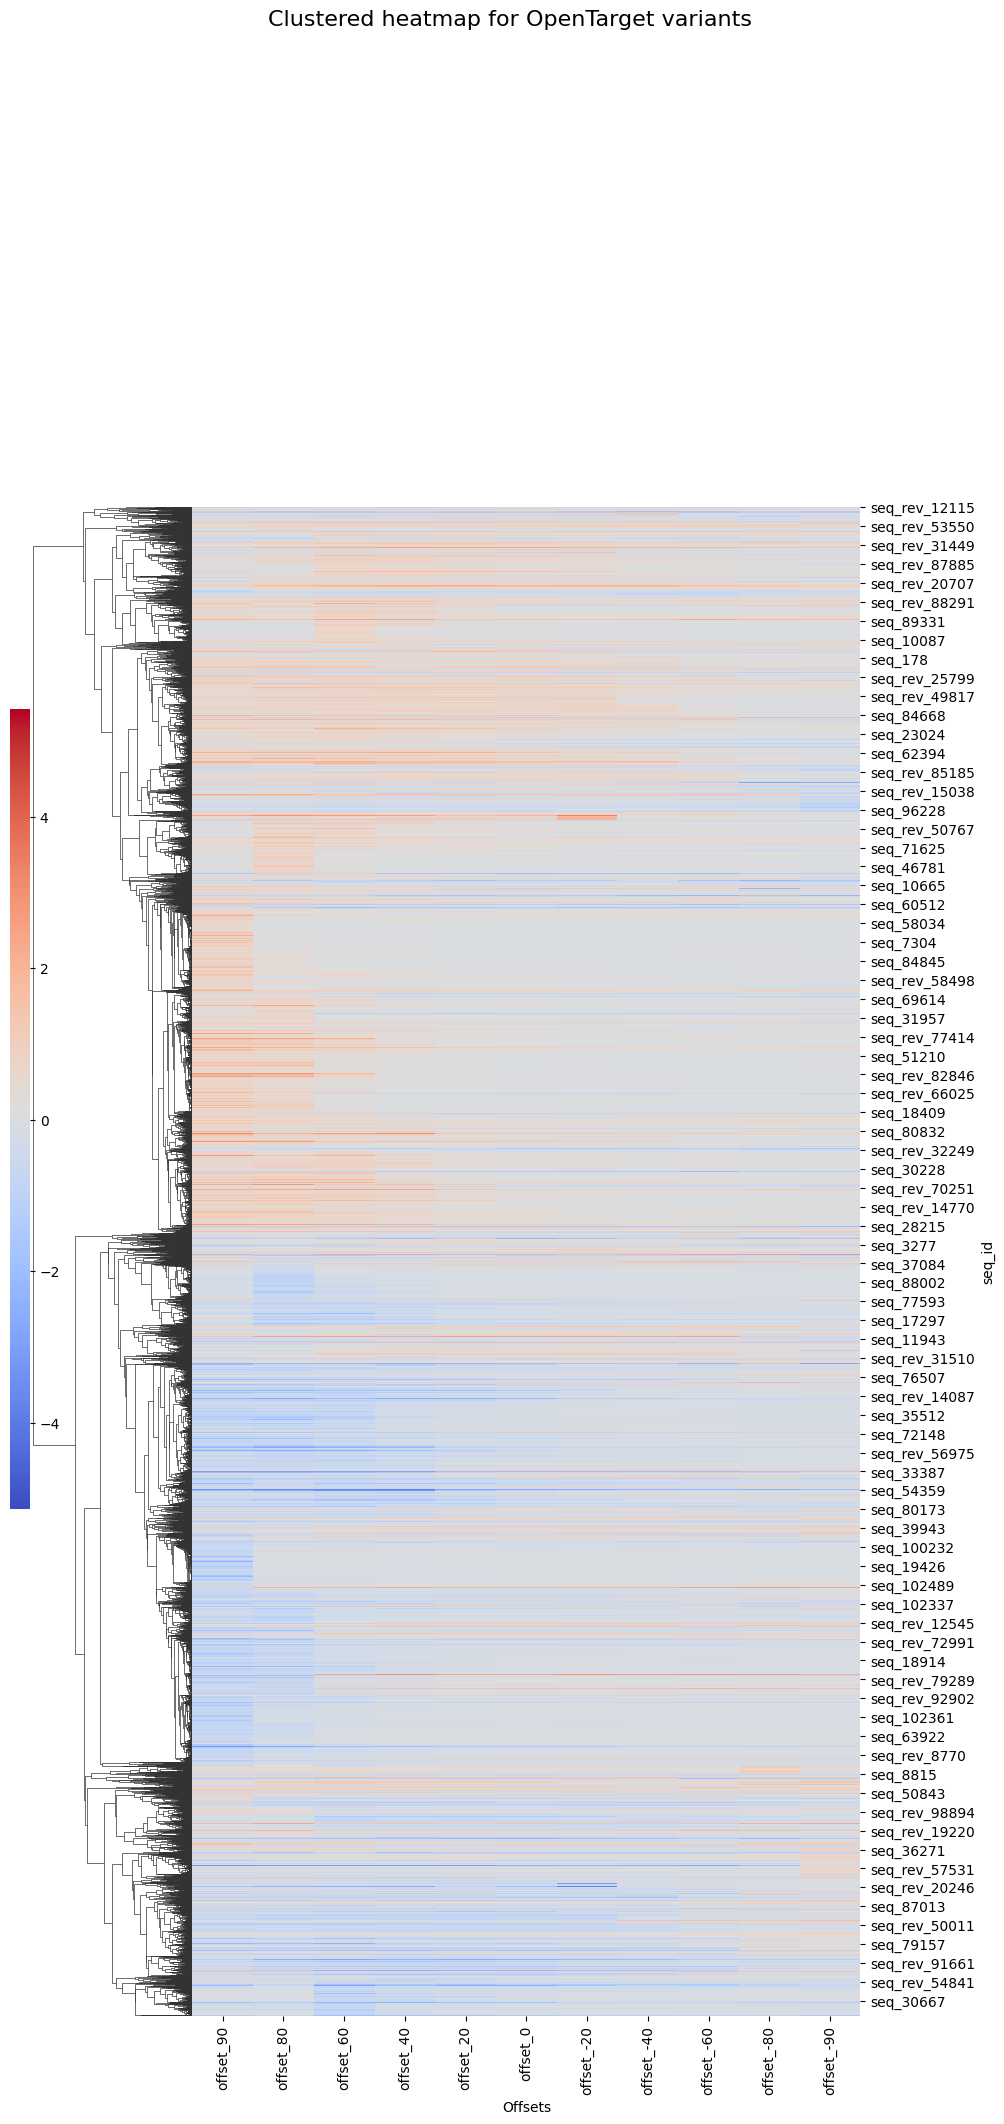

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

offset_cols = [col for col in combined.columns if col.startswith('offset_')]

filtered = combined[combined[offset_cols].apply(
    lambda row: (row > 0.5).any() or (row < -0.5).any(), axis=1)]

print(len(filtered))
heatmap_data = filtered[offset_cols]
heatmap_data.index = filtered['seq_id']  

g = sns.clustermap(
    heatmap_data,
    cmap='coolwarm',
    metric='correlation', 
    method='average',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None
)

g.cax.set_position([0, .3, .02, .4])
g.ax_heatmap.set_xlabel("Offsets")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=0, fontsize=16, ha='center')

plt.show()


21303


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


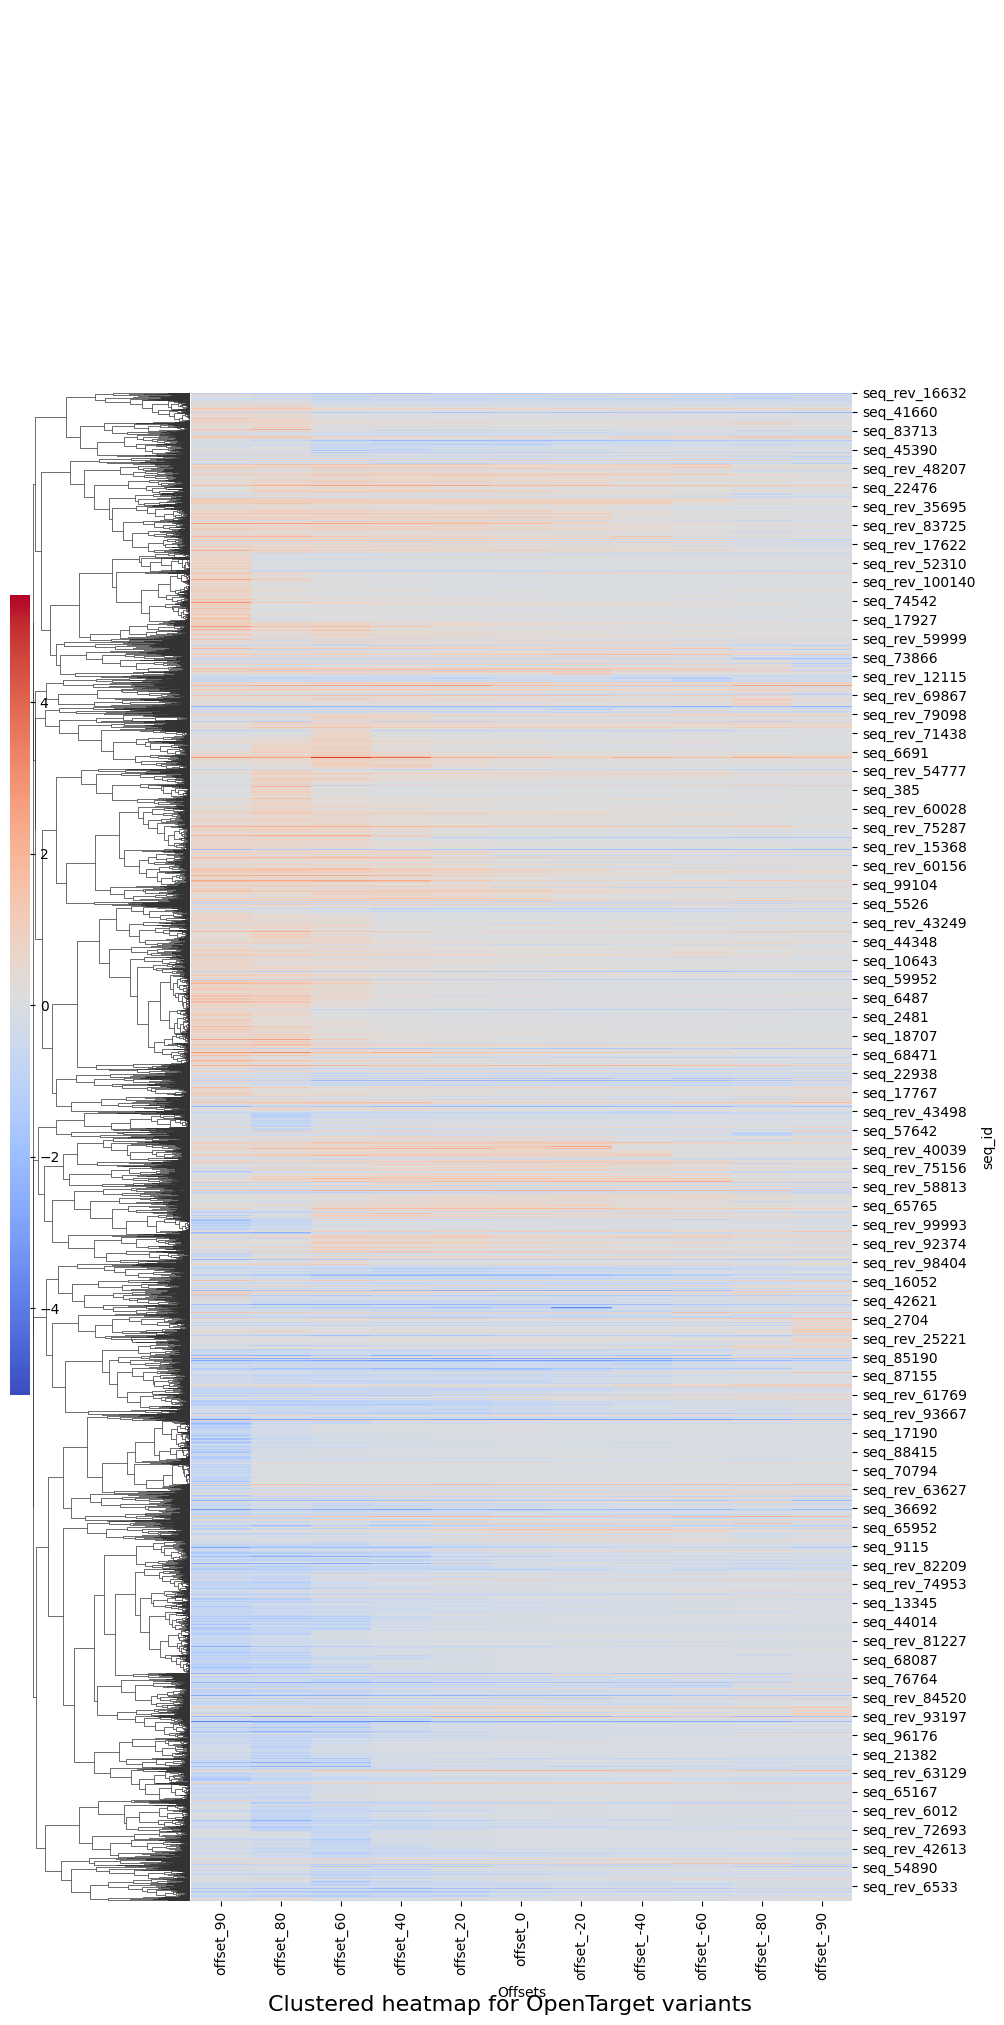

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

offset_cols = [col for col in combined.columns if col.startswith('offset_')]

filtered = combined[combined[offset_cols].apply(
    lambda row: (row > 0.5).any() or (row < -0.5).any(), axis=1)]

print(len(filtered))
heatmap_data = filtered[offset_cols]
heatmap_data.index = filtered['seq_id']  

g = sns.clustermap(
    heatmap_data,
    cmap='coolwarm',
    metric='correlation', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None
)

g.cax.set_position([0, .3, .02, .4])
g.ax_heatmap.set_xlabel("Offsets")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=0, fontsize=16, ha='center')

plt.show()


21303


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


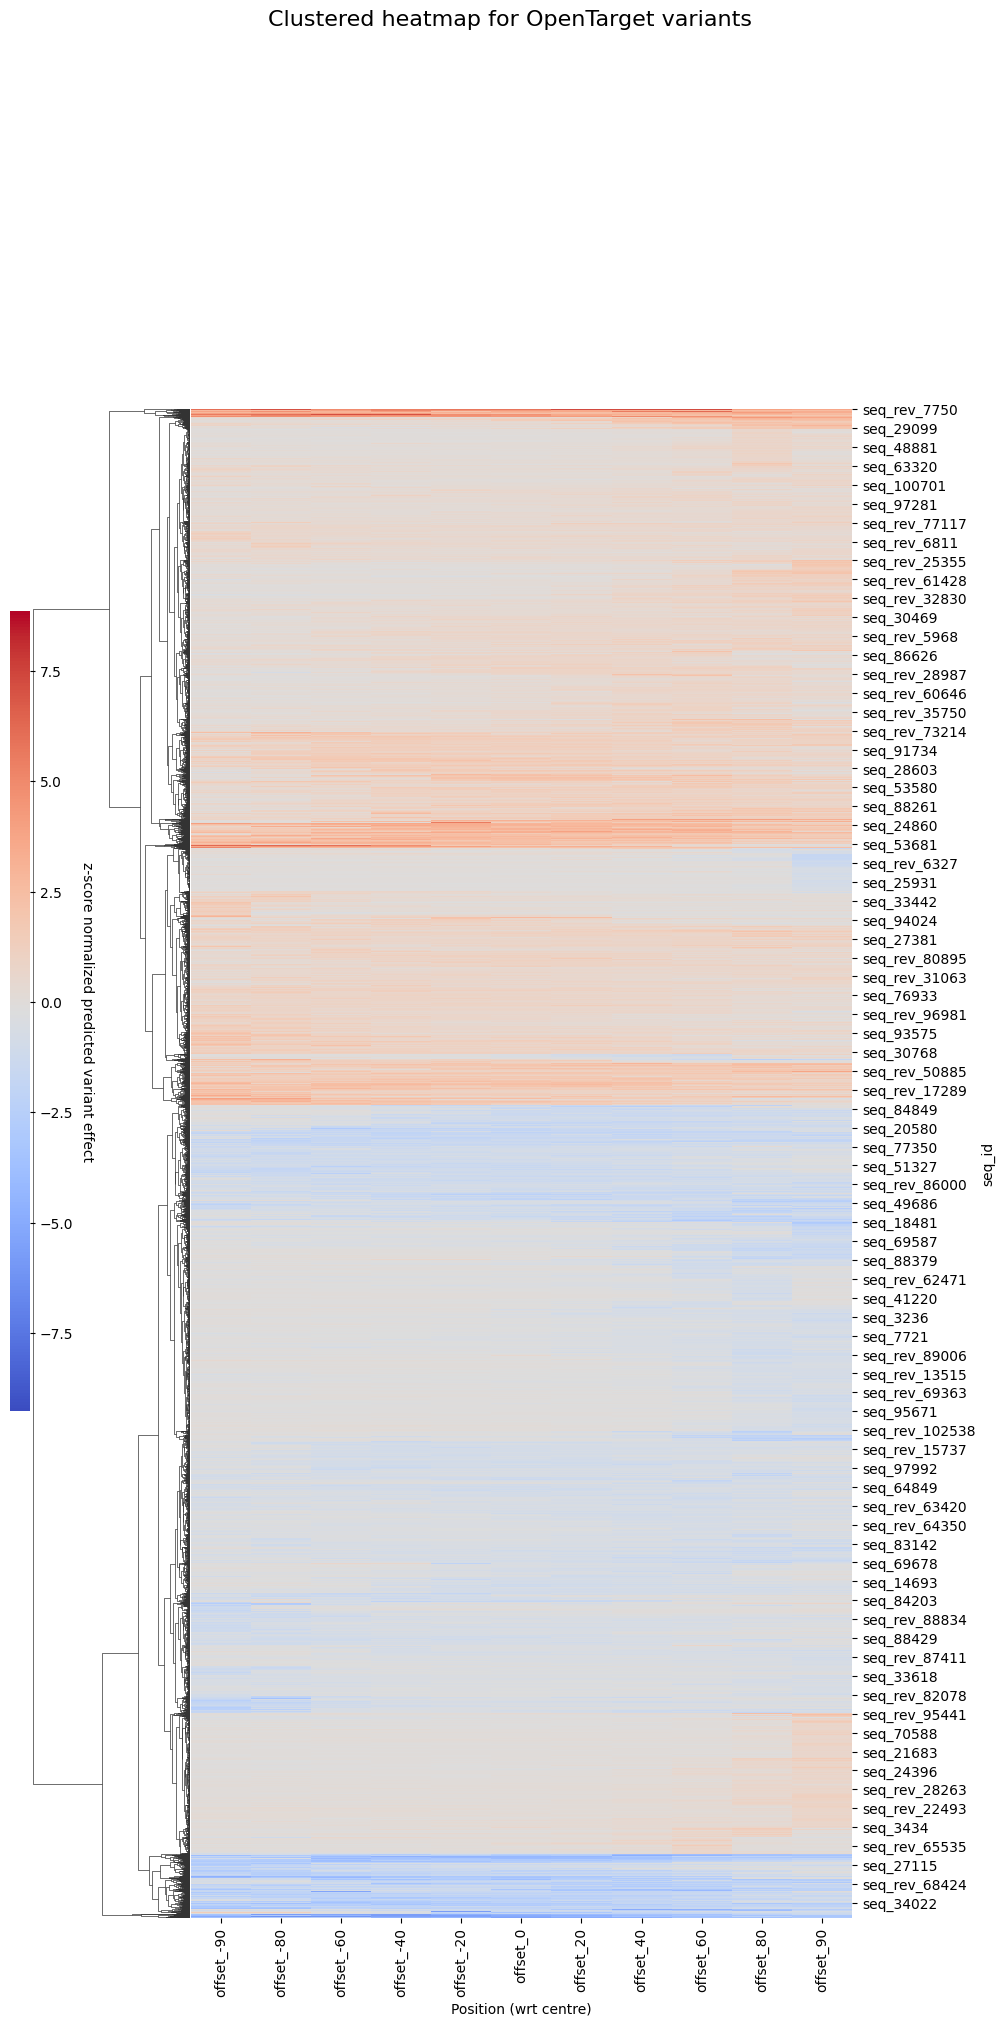

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

offset_cols = [col for col in combined.columns if col.startswith('offset_')]

renamed_cols = {}
for col in offset_cols:
    offset_val = int(col.split('_')[1])
    renamed_cols[col] = f"offset_{-(offset_val)}"

combined = combined.rename(columns=renamed_cols)
new_offset_cols = sorted(renamed_cols.values(), key=lambda x: int(x.split('_')[1]))


filtered = combined[combined[new_offset_cols].apply(
    lambda row: (row > 0.5).any() or (row < -0.5).any(), axis=1)]

print(len(filtered))
heatmap_data = filtered[new_offset_cols]
heatmap_data.index = filtered['seq_id']  

g = sns.clustermap(
    heatmap_data,
    cmap='coolwarm',
    metric='euclidean', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=1,
    standard_scale=None
)

g.cax.set_position([0, .3, .02, .4])
g.cax.set_ylabel("z-score normalized predicted variant effect", rotation=270, labelpad=15)

g.ax_heatmap.set_xlabel("Position (wrt centre)")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=1.001, fontsize=16, ha='center')

plt.show()
